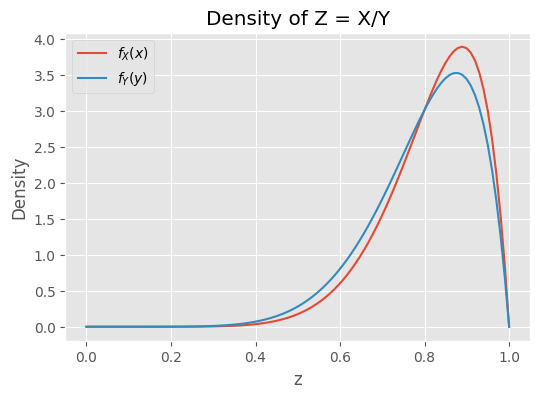

In [14]:
from scipy.stats import beta
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
a1, b1, a2, b2 = 9, 2, 8, 2
fx = lambda x: beta.pdf(x, a1, b1)
fy = lambda y: beta.pdf(y, a2, b2)

z = np.linspace(0, 1, 100)
fz = np.zeros(len(z))
for i in range(len(z)):
    intergrand = lambda y: fy(y) * fx(z[i]/y)/y
    fz[i] = integrate.quad(intergrand, z[i], 1)[0]

fig = plt.figure(figsize=(6, 4))   
plt.plot(z, fx(z), label='$f_X(x)$')    
plt.plot(z, fy(z), label='$f_Y(y)$')
plt.xlabel('z')
plt.ylabel('Density')
plt.style.use('ggplot')
plt.title('Density of Z = X/Y')
plt.grid(True)
plt.legend()
plt.show()



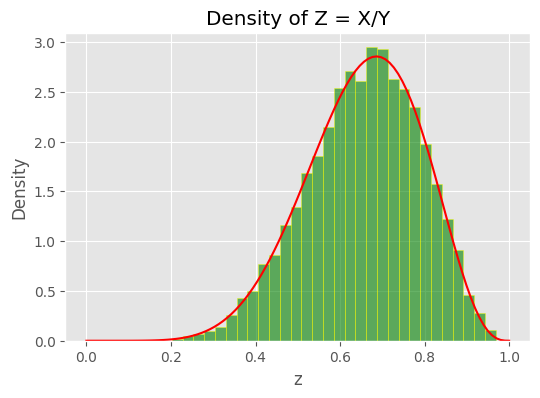

In [28]:
a1, b1, a2, b2 = 9, 2, 8, 2 
n = 10000
x = beta.rvs(a1, b1, size=n)
y = beta.rvs(a2, b2, size=n) 
z = x*y

x = np.linspace(0, 1, 100)
def f(z):
    fxy = lambda y: fy(y) * fx(z/y)/y
    tmp = integrate.quad(fxy, z, 1)
    return tmp[0]
fz = np.vectorize(f)(x)    
 

fig = plt.figure(figsize=(6, 4))    
plt.hist(z, bins=30, density=True, alpha=0.6, color='g', edgecolor='yellow') 
plt.plot(x, fz, color='red', label='f_Z(z)')
plt.xlabel('z')
plt.ylabel('Density')
plt.style.use('ggplot')
plt.title('Density of Z = X/Y')
plt.grid(True)
plt.show()
